# Aprendizaje Automático
**Maestro: Jorge Ramon Taveras Gonzáles**

**Edwin Pérez Santana 2024-0517**

**Idelsa Maria lugo Nivar 2024-0518**

**Angel Abreu 2024-0524**

**Luis González 2024-0509**

## Análisis Exploratorio de Datos

# **2.1 Comprensión del conjunto de datos:**

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
df = iris.frame
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df.drop(columns="target", inplace=True)

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**Tipo de variables**

In [ ]:
df.dtypes


,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


**Tamaño del dataset**

In [ ]:
df.shape


(150, 5)

# **2.2 Estadística descriptiva**

**Tendencia central**

In [ ]:
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode().iloc[0]


,0
sepal length (cm),5.0
sepal width (cm),3.0
petal length (cm),1.4
petal width (cm),0.2
species,setosa


**Dispersión**

In [ ]:
df.var(numeric_only=True)
df.std(numeric_only=True)
df.max(numeric_only=True) - df.min(numeric_only=True)  # Rango


,0
sepal length (cm),3.6
sepal width (cm),2.4
petal length (cm),5.9
petal width (cm),2.4


**Distribución**

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

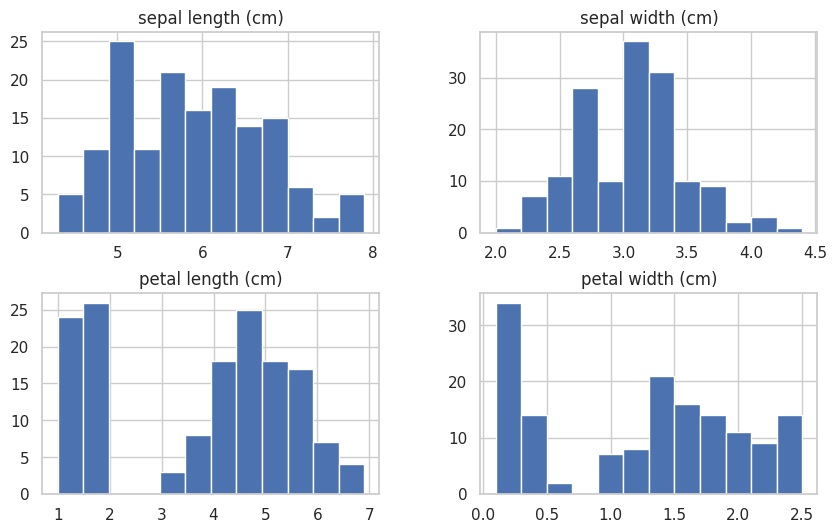

In [ ]:
df.hist(bins=12, figsize=(10,6))


**Outliers (IQR)**

In [ ]:
num_df = df.select_dtypes(include='number')

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR)))
outliers.sum()


,0
sepal length (cm),0
sepal width (cm),4
petal length (cm),0
petal width (cm),0


In [ ]:
num_df = df.select_dtypes(include='number')

Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)
IQR = Q3 - Q1

outlier_rows = df[(num_df < (Q1 - 1.5 * IQR)) | (num_df > (Q3 + 1.5 * IQR))].dropna(how='all')
outlier_rows


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
15,NaN,4.4,NaN,NaN,NaN
32,NaN,4.1,NaN,NaN,NaN
33,NaN,4.2,NaN,NaN,NaN
60,NaN,2.0,NaN,NaN,NaN


# **2.3 Limpieza de datos**

**Valores faltantes**

In [ ]:
df.isnull().sum()


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


**Tratamiento ejemplo**

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)


**Corrección de inconsistencias**

In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


# **2.4 Visualización de datos**

**Univariantes**

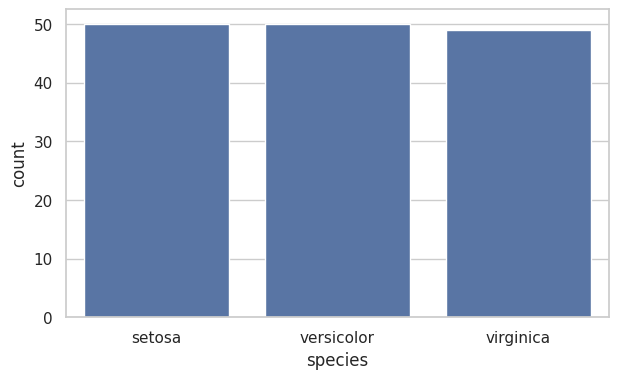

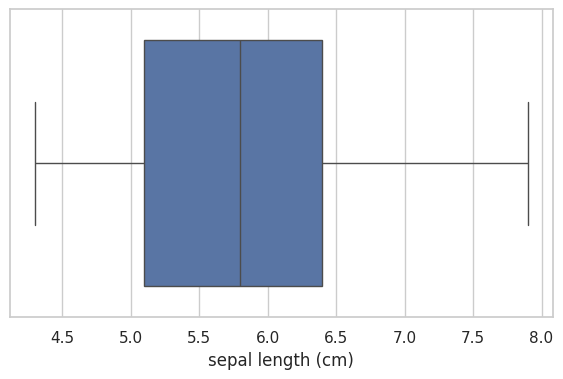

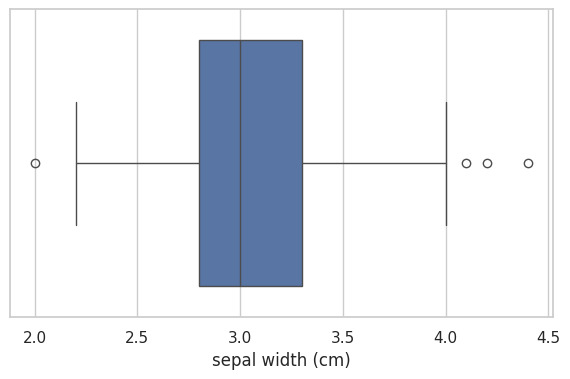

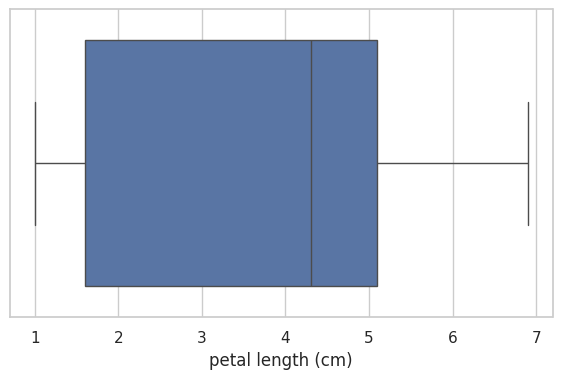

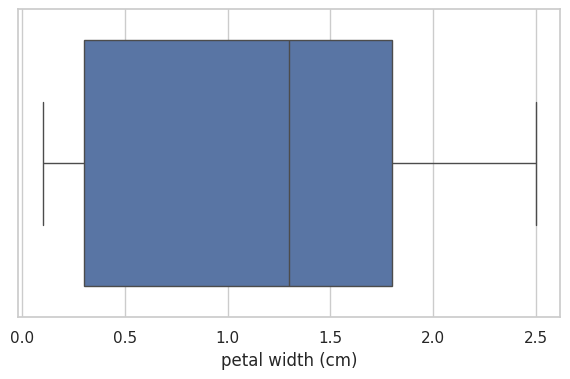

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="species", data=df)
plt.show()

for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.show()


**Bivariantes**

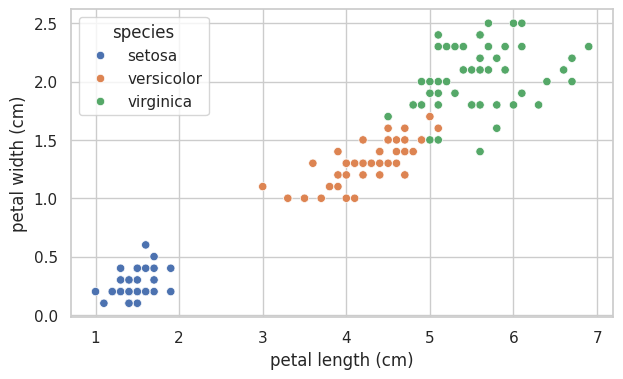

In [ ]:
sns.scatterplot(x="petal length (cm)", y="petal width (cm)", hue="species", data=df)
plt.show()


**Mapa de calor**

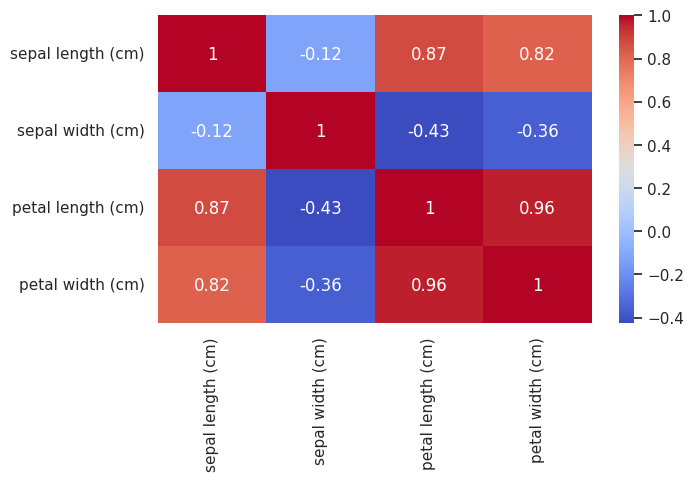

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


# **2.5 Correlaciones y relaciones**

In [ ]:
corr



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.118129,0.873738,0.820620
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894
petal length (cm),0.873738,-0.426028,1.000000,0.962772
petal width (cm),0.820620,-0.362894,0.962772,1.000000


**Relaciones no lineales**

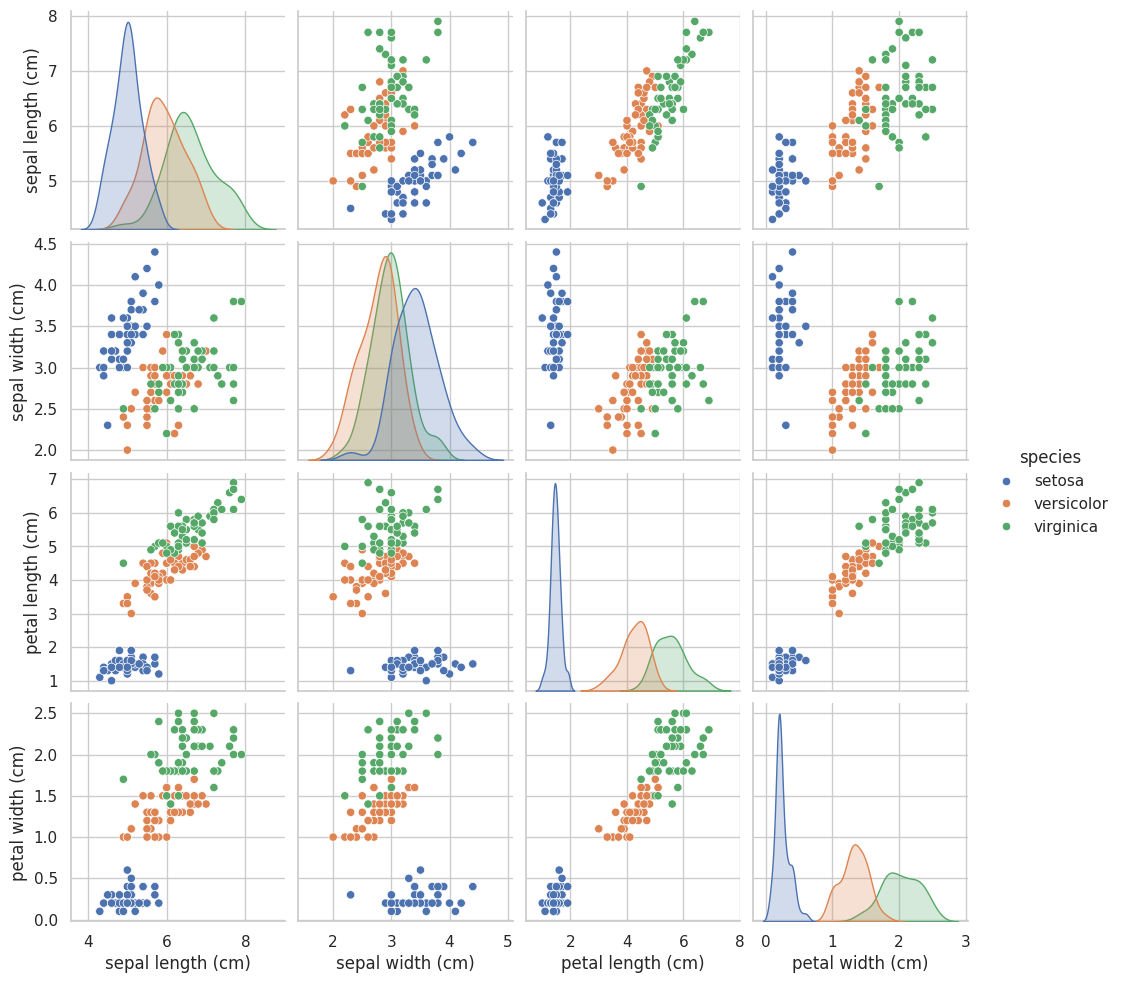

In [ ]:
sns.pairplot(df, hue="species")
plt.show()


# **2.6 Insights para el modelado**

**Variables más importantes**

Las que mejor separan especies:

petal length

petal width

**Escalado**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns="species"))


**Antes de escalar**

In [ ]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,149.000000,149.000000,149.000000,149.000000
mean,5.843624,3.059732,3.748993,1.194631
std,0.830851,0.436342,1.767791,0.762622
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.300000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Después de escalar**

In [ ]:
import pandas as pd
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns[:-1])
X_scaled_df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.490000e+02,1.490000e+02,1.490000e+02,1.490000e+02
mean,1.049124e-15,1.669060e-16,-1.430623e-16,-4.768743e-16
std,1.003373e+00,1.003373e+00,1.003373e+00,1.003373e+00
min,-1.864149e+00,-2.436862e+00,-1.560289e+00,-1.440192e+00
25%,-8.980334e-01,-5.972549e-01,-1.219738e+00,-1.177055e+00
50%,-5.268246e-02,-1.373532e-01,3.127435e-01,1.386329e-01
75%,6.719041e-01,5.524994e-01,7.668121e-01,7.964768e-01
max,2.483370e+00,3.081959e+00,1.788466e+00,1.717458e+00
